# Homework 10: Linear Regression

**Attention:**

1. **Using the Notebook**
    - Use Jupyter Notebook as instructed. We do **not** have the resources to support Anaconda or VS Code. 
    - Provide your answers in the designated spaces.
    - Do not reassign variables! For example, if you use `max_temperature` for one question, do not reassign it later on (e.g., as an intermediate variable). Doing so may cause you to fail tests you passed previously!
2. **Grading**:
    - Points may be scaled in Canvas.
    - Most tests check the format and data types of your answers, not their correctness. Passing the tests does not guarantee the grade will be 100%.
3. Academic honor:
    - **DO NOT CHEAT!** Academic honor matters.  
    - <font color='darkred'>**Use AI to LEARN, not to cheat**. **DO NOT copy-and-paste**</font>. Your advantage comes from your knowledge and skills on the subject. Do not rely on AI. 
    - Collaboration and using resources are encouraged, but **DO NOT directly share answers**. Always answer the questions and solve the problems by yourself. 
4. Getting help:
    - Attend the instructor's office hours.
5. <font color="darkred">**Time management**</font>: Start early in the assignment cycle and allocate enough time to complete the assignment properly.


**Recommended Readings**: 

* [Correlation](https://thinkdsm.org/chapters/12-regression/1201-correlation.html)
* [The Regression Line](https://thinkdsm.org/chapters/12-regression/1202-regression-line.html)
* [Method of Least Squares](https://thinkdsm.org/chapters/12-regression/1203-least-squares.html)
* [Least Squares Regression](https://thinkdsm.org/chapters/12-regression/1204-visual-diag-residual.html)

In [4]:
# Initialize Otter
import otter
grader = otter.Notebook("hw10.ipynb")

In [5]:
# Run this cell to set up the notebook, but please don't change it.

import numpy as np
import pandas as pd
from datascience import * 

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)
from datetime import datetime

## 1. Linear Regression Setup

When performing linear regression, we need to compute several important quantities which will be used throughout our analysis. **Unless otherwise specified when asked to make a prediction please assume we are predicting y from x throughout this assignment.** To help with our later analysis, we will begin by writing some of these functions and understanding what they can do for us.

**Question 1.1.** Define a function `standard_units` that converts a given array to standard units. **(3 points)**

*Hint:* You may find the `np.mean` and `np.std` functions helpful.


In [6]:
def standard_units(data):
    ...

In [ ]:
grader.check("q1_1")

**Question 1.2.** Which of the following are true about standard units? Assume we have converted an array of data into standard units using the function above. **(5 points)**

1. The unit of all our data when converted into standard units is the same as the unit of the original data.
2. The sum of all our data when converted into standard units is 0.
3. The standard deviation of all our data when converted into standard units is 1.
4. Adding a constant, C, to our original data has no impact on the resultant data when converted to standard units.
5. Multiplying our original data by a positive constant, C (>0), has no impact on the resultant data when converted to standard units.

Assign `standard_array` to an numpy array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `standard_array` to `make_array(1, 3, 5)`.


In [8]:
standard_array = ...

In [ ]:
grader.check("q1_2")

**Question 1.3.** Define a function `correlation` that computes the correlation between 2 arrays of data in original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [10]:
def correlation(x, y):
    ...

In [ ]:
grader.check("q1_3")

**Question 1.4.** Which of the following are true about the correlation coefficient $r$? **(5 points)**

1. The correlation coefficient measures the strength of a linear relationship.
2. When looking at the existing data, a correlation coefficient of 1.0 means an increase in one variable always means an increase in the other variable.
3. The correlation coefficient is the slope of the regression line in standard units.
4. The correlation coefficient stays the same if we swap our x-axis and y-axis.
5. If we add a constant, C, to our original data, our correlation coefficient will increase by the same C.

Create `r_array` to be a numpy array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,


In [12]:
r_array = ...

In [ ]:
grader.check("q1_4")

**Question 1.5.** Define a function `slope` that computes the slope of our line of best fit (to predict y given x), given two arrays of data in original units. Assume we want to create a line of best fit in original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [14]:
def slope(x, y):
    ...

In [ ]:
grader.check("q1_5")

**Question 1.6.** Which of the following are true about the slope of our line of best fit? Assume `x` refers to the value of one variable that we use to predict the value of `y`. **(5 points)**

1. In original units, the slope has the unit: unit of x / unit of y.
2. In standard units, the slope is unitless.
3. In original units, the slope is unchanged by swapping x and y.
4. In standard units, a slope of 1 means our data is perfectly linearly correlated.
5. In original units and standard units, the slope always has the same positive or negative sign.

Assign `slope_array` as a numpy array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,


In [16]:
slope_array = ...

In [ ]:
grader.check("q1_6")

**Question 1.7.** Define a function `intercept` that computes the intercept of our line of best fit (to predict y given x), given 2 arrays of data in original units. Assume we want to create a line of best fit in original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [18]:
def intercept(x, y):
    ...

In [ ]:
grader.check("q1_7")

**Question 1.8.** Which of the following are true about the intercept of our line of best fit? Assume `x` refers to the value of one variable that we use to predict the value of `y`. **(5 points)**

1. In original units, the intercept has the same unit as the y values.
2. In original units, the intercept has the same unit as the x values.
3. In original units, the slope and intercept have the same unit.
4. In standard units, the intercept for the regression line is 0.
5. In original units and standard units, the intercept always has the same numerical value.

Assign `intercept_array` to be a numpy array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,


In [20]:
intercept_array = ...

In [ ]:
grader.check("q1_8")

**Question 1.9.** Define a function `predict` that takes in a table and 2 column names, and returns an array of predictions. The predictions should be created using a fitted **regression line**. We are predicting `"col2"` from `"col1"`, both in original units. **(5 points)**

*Hint 1:* Feel free to use functions you have defined previously.

*Hint 2:* Re-reading [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#the-regression-line) might be helpful here.

Note: The public tests are quite comprehensive for this question, so passing them means that your function most likely works correctly.


In [ ]:
def predict(tbl, col1, col2):
    import pandas as pd
    if isinstance(tbl, pd.DataFrame):   ### pandas DataFrame
        x = ...
        y = ...
    else:
        x = tbl.column(col1)   # datascience Table
        y = tbl.column(col2)
    return intercept(x, y) + slope(x, y) * x

In [ ]:
grader.check("q1_9")

## 2. FIFA Predictions

The following data was scraped from [sofifa.com](https://sofifa.com/), a website dedicated to collecting information from FIFA video games. The dataset consists of all players in FIFA 22 and their corresponding attributes. We have truncated the dataset to a limited number of rows (100) to ease with our visualizations and analysis. Since we’re learning about linear regression, we will look specifically for a linear association between various player attributes. **To help with understanding where the line of best fit generated in linear regression comes from please do not use the `.fit_line` argument in `.scatter` at any point on question 2 unless the code was provided for you.**

Feel free to read more about the video game on [Wikipedia](https://en.wikipedia.org/wiki/FIFA_22).

In [24]:
# Run this cell to load the data
fifa = pd.read_csv('fifa22.csv')

# Select a subset of columns to analyze (there are 110 columns in the original dataset)
fifa = fifa[["short_name", "overall", "value_eur", "wage_eur", "age", "pace", "shooting", "passing", "attacking_finishing"]]
fifa.head(5)

,short_name,overall,value_eur,wage_eur,age,pace,shooting,passing,attacking_finishing
0,L. Messi,93,78000000,320000,34,85.0,92.0,91.0,95
1,R. Lewandowski,92,119500000,270000,32,78.0,92.0,79.0,95
2,Cristiano Ronaldo,91,45000000,270000,36,87.0,94.0,80.0,95
3,Neymar Jr,91,129000000,270000,29,91.0,83.0,86.0,83
4,K. De Bruyne,91,125500000,350000,30,76.0,86.0,93.0,82


<!-- BEGIN QUESTION -->

**Question 2.1.** Before jumping into any statistical techniques, it’s important to see what the data looks like, because data visualizations allow us to uncover patterns in our data that would have otherwise been much more difficult to see. **(3 points)**

Create a scatter plot with age on the x-axis (“age”), and the player’s value in Euros (“value_eur”) on the y-axis.


In [ ]:
import matplotlib.pyplot as plt

fifa.plot...
plt.show()

<!-- END QUESTION -->

**Question 2.2.** Does the correlation coefficient `r` for the data in our scatter plot in 2.1 look closest to 0, 0.75, or -0.75? **(3 points)**

Assign `r_guess` to one of 0, 0.75, or -0.75.


In [ ]:
r_guess = ...

In [ ]:
grader.check("q2_2")

<!-- BEGIN QUESTION -->

**Question 2.3.** Create a scatter plot with player age ("age") along the x-axis and both real player value ("value_eur") and predicted player value along the y-axis. The predictions should be created using a fitted **regression line**. The color of the dots for the real player values should be different from the color for the predicted player values. **(8 points)**

*Hint 1:* Feel free to use functions you have defined previously.

*Hint 2:* [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#) and [7.3](https://inferentialthinking.com/chapters/07/3/Overlaid_Graphs.html#overlaid-scatter-plots) has examples of creating such scatter plots.


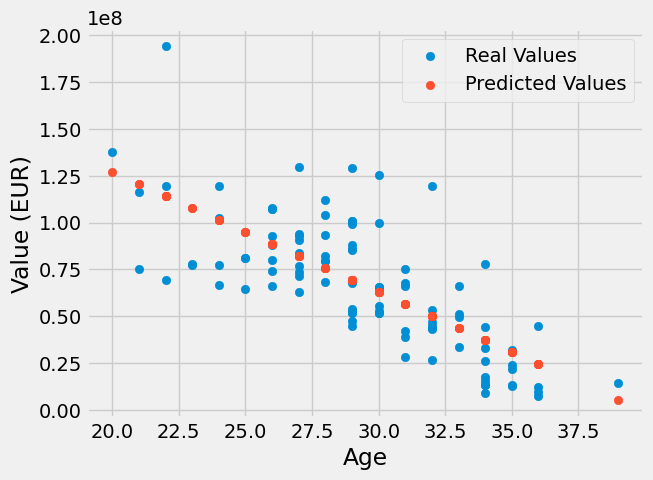

In [ ]:
# predictions = ...
# fifa_with_predictions = ...
# ...

# Step 1: get predictions
predictions = ...
# Step 2: add predictions as a new column
fifa["predicted_value"] = ...
# Step 3: create scatter plot
import matplotlib.pyplot as plt
plt.scatter(fifa["age"], fifa["value_eur"], label="Real Values")
plt.scatter(fifa["age"], fifa["predicted_value"], label="Predicted Values")

plt.xlabel("Age")
plt.ylabel("Value (EUR)")
plt.legend()
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.4.** Looking at the scatter plot you produced above, is linear regression a good model to use? If so, what features or characteristics make this model reasonable? If not, what features or characteristics make it unreasonable? **(5 points)**


_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.5.** In 2.3, we created a scatter plot **in original units**. Now, create a scatter plot with player age **in standard units** along the x-axis and both real and predicted player value **in standard units** along the y-axis. The color of the dots of the real and predicted values should be different. **(8 points)**

*Hint:* Feel free to use functions you have defined previously.


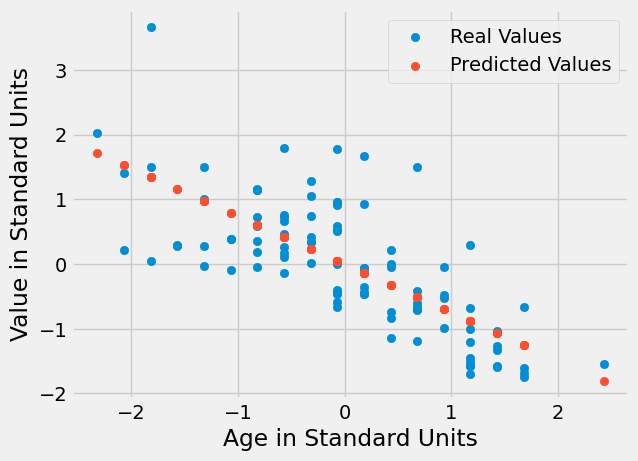

In [ ]:
# predictions_su = ...
# fifa_su = ...
# ...

age_su = ...
value_su = ...

r = ...
predicted_value_su = ...

plt.scatter(age_su, value_su, label="Real Values")
plt.scatter(age_su, predicted_value_su, label="Predicted Values")

plt.xlabel("Age in Standard Units")
plt.ylabel("Value in Standard Units")
plt.legend()
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.6.** Compare your plots in 2.3 and 2.5. What similarities do they share? What differences do they have? **(5 points)**


_Type your answer here, replacing this text._

<!-- END QUESTION -->

**Question 2.7.** Define a function `rmse` that takes in two arguments: a slope and an intercept for a potential regression line. The function should return the root mean squared error between the values predicted by a regression line with the given slope and intercept and the actual outcomes. **(6 points)**

Assume we are still predicting “value_eur” from “age” in original units from the `fifa` table.


In [29]:
def rmse(slope, intercept):
    predictions = intercept + slope * fifa["age"]
    errors = fifa["value_eur"] - predictions
    return np.sqrt(np.mean(errors**2))

In [ ]:
grader.check("q2_7")

<!-- BEGIN QUESTION -->

**Question 2.8.** Use the `rmse` function you defined along with `minimize` to find the least-squares regression parameters predicting player value from player age. Here's an [example](https://inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html#numerical-optimization) of using the `minimize` function from the textbook. **(10 points)**

Then set `lsq_slope` and `lsq_intercept` to be the least-squares regression line slope and intercept, respectively.

Finally, create a scatter plot like you did in 2.3 with player age ("age") along the x-axis and both real player value ("value_eur") and predicted player value along the y-axis. **Be sure to use your least-squares regression line to compute the predicted values.** The color of the dots for the real player values should be different from the color for the predicted player values.

> **Note:** Your solution should not make any calls to the slope or intercept functions defined earlier.

*Hint:* Your call to `minimize` will return an array of argument values that minimize the return value of the function passed to `minimize`.

Slope: -6.41462e+06 | Intercept: 2.55525e+08


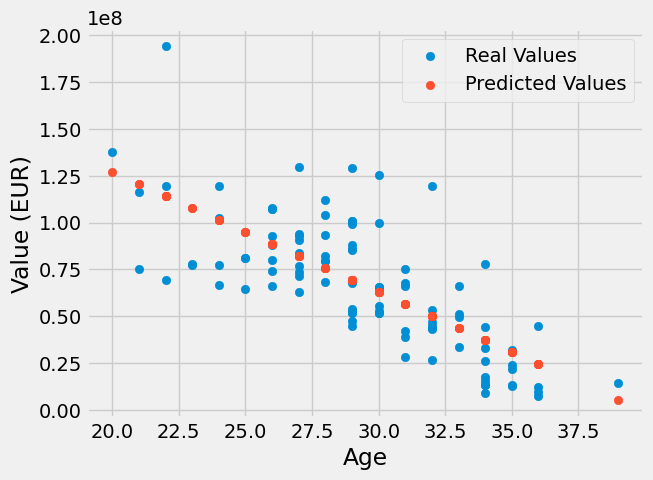

In [ ]:
# Step 1: minimize RMSE
# from scipy.optimize import minimize 
# DO NOT import scipy minimize

minimized_parameters = minimize(rmse)

lsq_slope = ...
lsq_intercept = ...

print(f"Slope: {lsq_slope:g} | Intercept: {lsq_intercept:g}")

fifa["predicted_value"] = lsq_intercept + lsq_slope * fifa["age"]

import matplotlib.pyplot as plt

plt.scatter(fifa["age"], fifa["value_eur"], label="Real Values")
plt.scatter(fifa["age"], fifa["predicted_value"], label="Predicted Values")

plt.xlabel("Age")
plt.ylabel("Value (EUR)")
plt.legend()
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 2.9.** The resulting line you found in 2.8 should appear very similar to the line you found in 2.3. Why were we able to minimize RMSE to find nearly the same slope and intercept from the previous formulas? **(5 points)**

*Hint:* Re-reading [15.3](https://inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html#the-least-squares-line) might be helpful here.


_Type your answer here, replacing this text._

<!-- END QUESTION -->

**Question 2.10** For which of the following error functions would we have resulted in the same slope and intercept values in 2.8 instead of using RMSE? Assume `error` is assigned to the actual values minus the predicted values. **(5 points)**

1. `np.sum(error) ** 0.5`
2. `np.sum(error ** 2)`
3. `np.mean(error) ** 0.5`
4. `np.mean(error ** 2)`

Assign `error_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `error_array` to `make_array(1, 3, 5)`.

Hint: What was the purpose of RMSE? Are there any alternatives, and if so, does minimizing them them yield the same results as minimizing the RMSE? 

In [ ]:
error_array = ...

In [ ]:
grader.check("q2_10")

In [32]:
# goalies don't have shooting in our dataset so we removed them before looking at the pace stat
no_goalies = fifa[fifa["shooting"] > 0]

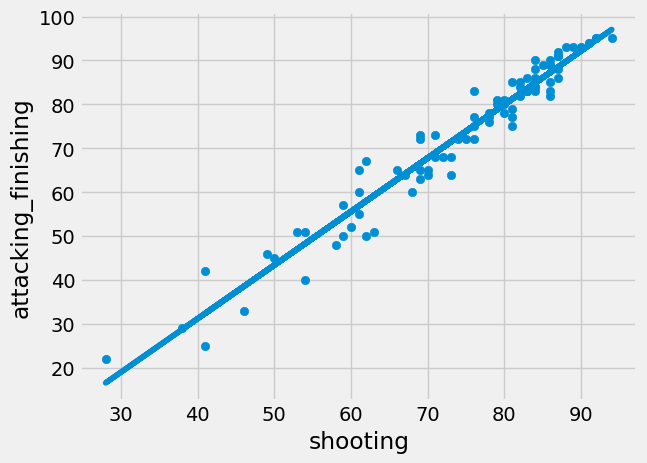

In [33]:
# Run this cell to generate a scatter plot for the next part.
import matplotlib.pyplot as plt
import numpy as np

x = no_goalies["shooting"]
y = no_goalies["attacking_finishing"]

# Scatter plot
plt.scatter(x, y)

# Fit regression line (like fit_line=True)
slope, intercept = np.polyfit(x, y, 1)
plt.plot(x, intercept + slope * x)

plt.xlabel("shooting")
plt.ylabel("attacking_finishing")
plt.show()

**Question 2.11.** Above is a scatter plot showing the relationship between a player’s shooting ability (“shooting”) and their scoring ability (“attacking_finishing”). 

There is clearly a strong positive correlation between the 2 variables, and we’d like to predict a player’s scoring ability from their shooting ability. Which of the following are true, assuming linear regression is a reasonable model? **(5 points)**

*Hint:* Re-reading [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#) might be helpful here.

1. For a majority of players with a `shooting` attribute above 80 our model predicts they have a better scoring ability than shooting ability.
2. A randomly selected player's predicted scoring ability in standard units will always be less than their shooting ability in standard units.
3. If we select a player who’s shooting ability is 1.0 in standard units, their scoring ability, on average, will be less than 1.0 in standard units.
4. Goalies have attacking_finishing scores in our dataset but do not have shooting scores. We can still use our model to predict their attacking_finishing scores.

Assign `scoring_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `scoring_array` to `make_array(1, 3, 5)`.


In [ ]:
scoring_array = ...

In [ ]:
grader.check("q2_11")

<p>&nbsp;</p>

`Good Job! You are done with this assignment!`

## Submission Instructions

Follow these steps to submit your work:

1. Save your notebook file:
   - Click on File -> Save Notebook, or simply click on the Save icon.
2. Restart Kernel and Run All Cells:
   - In the menu, go to Kernel → Restart Kernel and Run All Cells.
3. Verify your work:
   - Scroll through the notebook to ensure everything runs smoothly without unexpected error messages. 
   - In case of interruptions caused by execution errors, use Run Selected Cell and All Below to continue execution. 
4. Save the notebook again to confirm all changes.
5. Create a duplicate notebook for submission:
   - In the Jupyter Notebook dashboard/homepage, create a duplicate of this notebook
   - Rename the duplicate from *assignment.ipynb_copy* to *assignment_FIRSTNAME_LASTNAME.ipynb* (e.g., *a01_TSANGYAO_CHEN.ipynb*) for submission.
   - Keep your original notebook file as a backup.
6. Upload your renamed notebook to Canvas.